In [2]:
!pip install scipy statsmodels plotly --quiet  # install statistical and interactive plotting libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats  # for all hypothesis tests
from statsmodels.tsa.seasonal import seasonal_decompose  # for time series decomposition
from statsmodels.stats.multicomp import pairwise_tukeyhsd  # for Tukey HSD post-hoc test
from statsmodels.stats.stattools import durbin_watson  # for residual diagnostics
import warnings
warnings.filterwarnings('ignore')  # suppress non-critical warnings for cleaner output

plt.style.use('seaborn-v0_8-whitegrid')  # clean plot style
sns.set_palette('husl')  # distinct colours for multi-category plots

# Load master CSV from Phase 1
master = pd.read_csv('./processed/bangalore_master_aqi.csv')  # load the cleaned dataset
master['Date'] = pd.to_datetime(master['Date'], format="%d-%m-%Y")  # re-parse dates — CSV saves them as strings, specifying format
master = master.sort_values('Date').reset_index(drop=True)

print('Master loaded:', master.shape)
print('Columns:', master.columns.tolist())
print('Date range:', master['Date'].min().date(), '->', master['Date'].max().date())
print(master.head())

Master loaded: (2009, 12)
Columns: ['Date', 'year', 'month', 'season', 'day_of_week', 'AQI', 'PM2.5', 'PM10', 'temp', 'humidity', 'wind_speed', 'rainfall']
Date range: 2015-01-01 -> 2020-07-01
        Date  year  month  season day_of_week         AQI      PM2.5  \
0 2015-01-01  2015      1  Winter    Thursday  111.729032  46.894452   
1 2015-01-02  2015      1  Winter      Friday  111.729032  46.894452   
2 2015-01-03  2015      1  Winter    Saturday  111.729032  46.894452   
3 2015-01-04  2015      1  Winter      Sunday  111.729032  46.894452   
4 2015-01-05  2015      1  Winter      Monday  111.729032  46.894452   

         PM10  temp  humidity  wind_speed  rainfall  
0  101.797484  21.7        79        13.2       4.8  
1  101.797484  21.7        75        13.0       0.8  
2  101.797484  21.5        71        10.5       0.0  
3  101.797484  21.3        70        11.4       0.0  
4  101.797484  21.7        69        11.9       0.0  


###Exploratory Data Analysis

In [3]:
master['is_weekend'] = master['day_of_week'].isin(['Saturday', 'Sunday'])  # True for Sat/Sun, False for weekdays
master['is_weekend_label'] = master['is_weekend'].map({True: 'Weekend', False:
'Weekday'})  # readable label for plots

# Verify season mapping is correct
print('Season distribution:')
print(master.groupby('season')['month'].apply(lambda x:
sorted(x.unique())).to_string())
# Expected: Monsoon=[6,7,8,9], Post-Monsoon=[10,11], Summer=[3,4,5], Winter=[12,1,2]


Season distribution:
season
Monsoon         [6, 7, 8, 9]
Post-Monsoon        [10, 11]
Summer             [3, 4, 5]
Winter            [1, 2, 12]


In [4]:
#Univariate analysis
cols_of_interest = ['AQI', 'PM2.5', 'PM10', 'temp', 'humidity', 'wind_speed', 'rainfall']

stats_summary = master[cols_of_interest].describe().round(2)  # count, mean, std, min, quartiles, max
print('=== Descriptive Statistics ===')
print(stats_summary)

# Also compute skewness and kurtosis — important for choosing statistical tests later
print('\n=== Skewness (0=symmetric, >1=right skewed, <-1=left skewed) ===')
print(master[cols_of_interest].skew().round(3))

print('\n=== Kurtosis (0=normal, >0=heavy tails) ===')
print(master[cols_of_interest].kurt().round(3))

=== Descriptive Statistics ===
           AQI    PM2.5     PM10     temp  humidity  wind_speed  rainfall
count  2009.00  2009.00  2009.00  2009.00   2009.00     2009.00   2009.00
mean     94.99    35.79    82.75    23.45     68.12       17.19      2.53
std      40.00    21.56    35.68     2.27     14.34        5.31      5.67
min      20.00     1.72     8.22    17.40     26.00        5.50      0.00
25%      67.00    21.36    58.32    22.00     58.00       13.40      0.00
50%      88.00    31.21    76.88    23.00     71.00       16.60      0.20
75%     111.73    45.23   102.18    24.80     80.00       19.90      2.50
max     352.00   313.59   351.51    30.20     97.00       36.70    126.60

=== Skewness (0=symmetric, >1=right skewed, <-1=left skewed) ===
AQI           1.759
PM2.5         3.464
PM10          1.268
temp          0.569
humidity     -0.519
wind_speed    0.806
rainfall      7.383
dtype: float64

=== Kurtosis (0=normal, >0=heavy tails) ===
AQI             5.579
PM2.5          

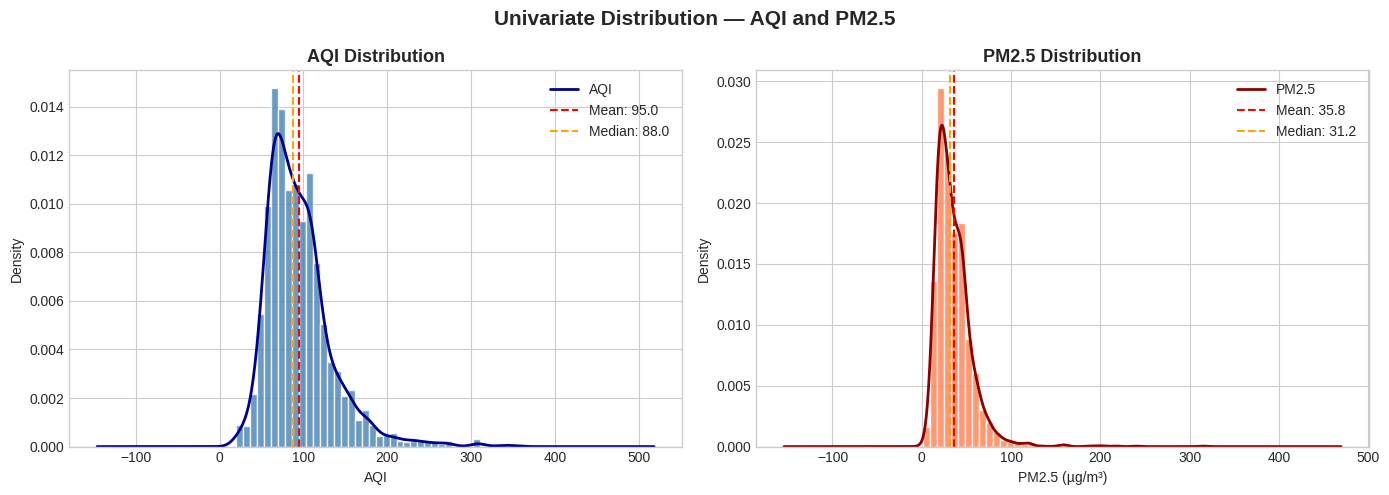

Saved: plot_01_histograms.png


In [5]:
import matplotlib.pyplot as plt # Ensure plt is defined

#histograms with KDE for AQI and PM2.5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AQI histogram
axes[0].hist(master['AQI'].dropna(), bins=40, color='steelblue',
edgecolor='white', alpha=0.8, density=True)  # density=True normalises to probability
master['AQI'].dropna().plot(kind='kde', ax=axes[0], color='darkblue', linewidth=2)
# overlay KDE curve
axes[0].axvline(master['AQI'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {master["AQI"].mean():.1f}')
axes[0].axvline(master['AQI'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {master["AQI"].median():.1f}')
axes[0].set_title('AQI Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].legend()

# PM2.5 histogram
axes[1].hist(master['PM2.5'].dropna(), bins=40, color='coral', edgecolor='white', alpha=0.8, density=True)
master['PM2.5'].dropna().plot(kind='kde', ax=axes[1], color='darkred', linewidth=2)
axes[1].axvline(master['PM2.5'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {master["PM2.5"].mean():.1f}')
axes[1].axvline(master['PM2.5'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {master["PM2.5"].median():.1f}')
axes[1].set_title('PM2.5 Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PM2.5 (µg/m³)')
axes[1].legend()

plt.suptitle('Univariate Distribution — AQI and PM2.5', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_01_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_01_histograms.png')

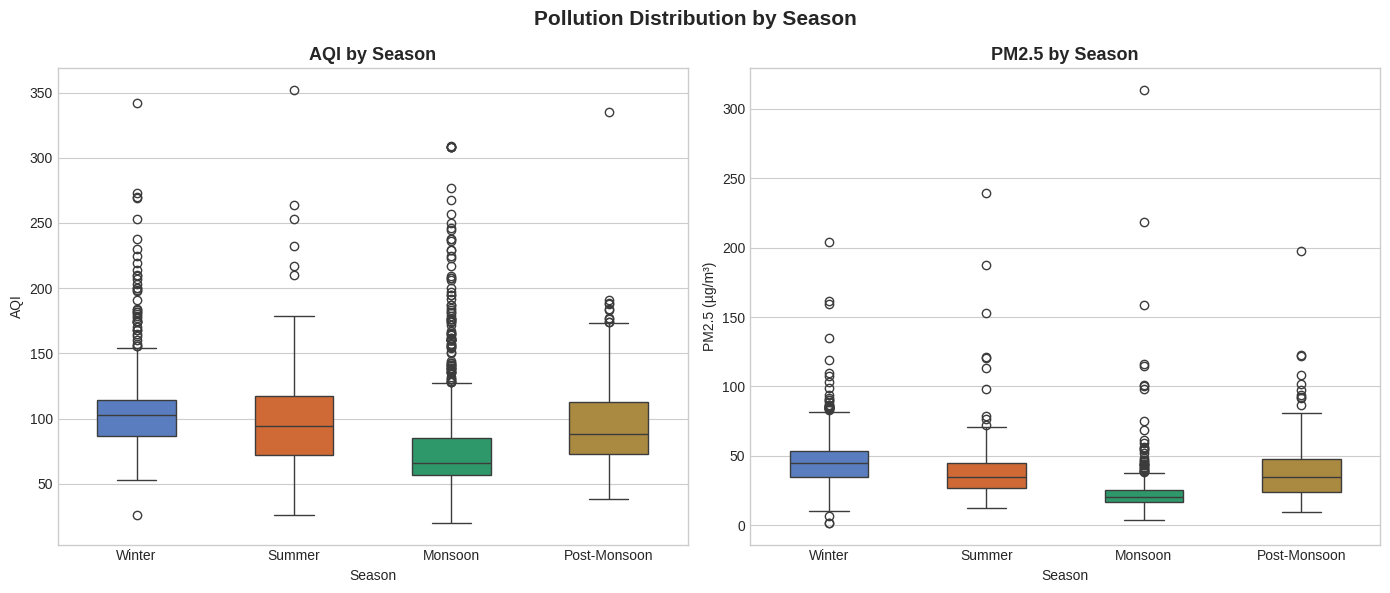

Median AQI by season:
season
Monsoon          66.0
Post-Monsoon     88.0
Summer           94.0
Winter          103.0
Name: AQI, dtype: float64


In [6]:
#boxplot by season
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_colors = {'Winter': '#4878CF', 'Summer': '#E8601C', 'Monsoon': '#1DAA6D', 'Post-Monsoon': '#BC8F2F'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# AQI boxplot by season
sns.boxplot(data=master, x='season', y='AQI', order=season_order,
palette=season_colors, ax=axes[0], width=0.5)
axes[0].set_title('AQI by Season', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('AQI')
# PM2.5 boxplot by season
sns.boxplot(data=master, x='season', y='PM2.5', order=season_order,
palette=season_colors, ax=axes[1], width=0.5)
axes[1].set_title('PM2.5 by Season', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('PM2.5 (µg/m³)')
plt.suptitle('Pollution Distribution by Season', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_02_boxplots_season.png', dpi=150,
bbox_inches='tight')
plt.show()
# Print median AQI per season for interpretation
print('Median AQI by season:')
print(master.groupby('season')['AQI'].median().round(1))


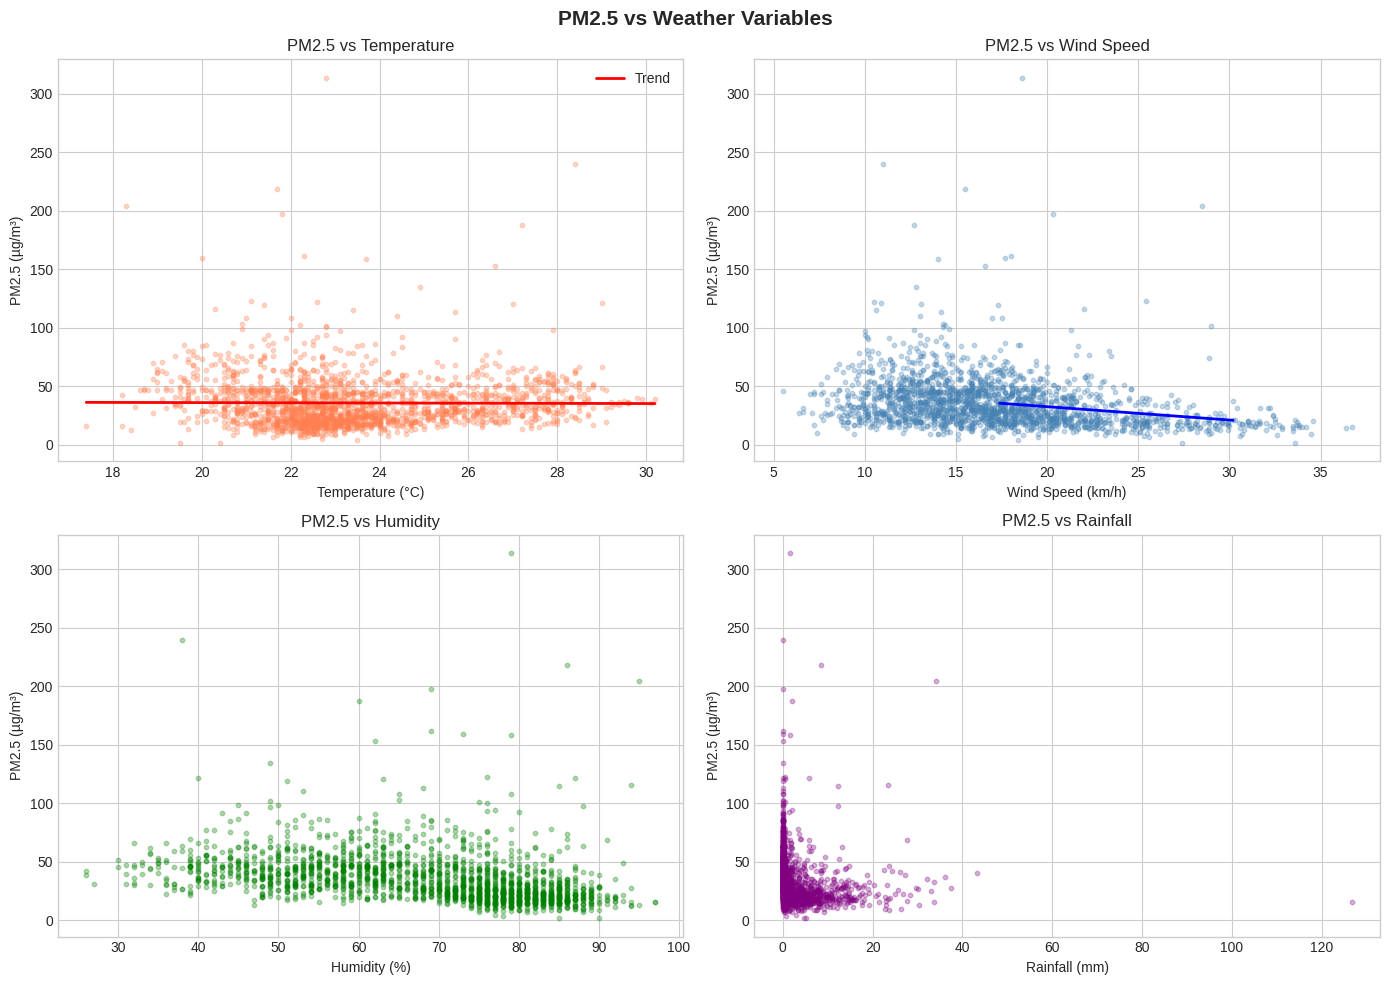

In [7]:
#Bivariate analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PM2.5 vs Temperature
axes[0,0].scatter(master['temp'], master['PM2.5'], alpha=0.3, s=10, color='coral')
# alpha=0.3 makes overlapping points visible
z = np.polyfit(master['temp'].dropna(), master['PM2.5'].dropna(), 1)  # fit a linear trend line
p_line = np.poly1d(z)
x_range = np.linspace(master['temp'].min(), master['temp'].max(), 100)
axes[0,0].plot(x_range, p_line(x_range), 'r-', linewidth=2, label='Trend')  # draw the trend line
axes[0,0].set_xlabel('Temperature (°C)')
axes[0,0].set_ylabel('PM2.5 (µg/m³)')
axes[0,0].set_title('PM2.5 vs Temperature')
axes[0,0].legend()

# PM2.5 vs Wind Speed
axes[0,1].scatter(master['wind_speed'], master['PM2.5'], alpha=0.3, s=10, color='steelblue')
z2 = np.polyfit(master['wind_speed'].dropna(), master['PM2.5'].dropna(), 1)
axes[0,1].plot(x_range, np.poly1d(z2)(x_range), 'b-', linewidth=2)
axes[0,1].set_xlabel('Wind Speed (km/h)')
axes[0,1].set_ylabel('PM2.5 (µg/m³)')
axes[0,1].set_title('PM2.5 vs Wind Speed')

# PM2.5 vs Humidity
axes[1,0].scatter(master['humidity'], master['PM2.5'], alpha=0.3, s=10, color='green')
axes[1,0].set_xlabel('Humidity (%)')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')
axes[1,0].set_title('PM2.5 vs Humidity')

# PM2.5 vs Rainfall
axes[1,1].scatter(master['rainfall'], master['PM2.5'], alpha=0.3, s=10, color='purple')
axes[1,1].set_xlabel('Rainfall (mm)')
axes[1,1].set_ylabel('PM2.5 (µg/m³)')
axes[1,1].set_title('PM2.5 vs Rainfall')

plt.suptitle('PM2.5 vs Weather Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_03_scatter_bivariate.png', dpi=150,
bbox_inches='tight')
plt.show()


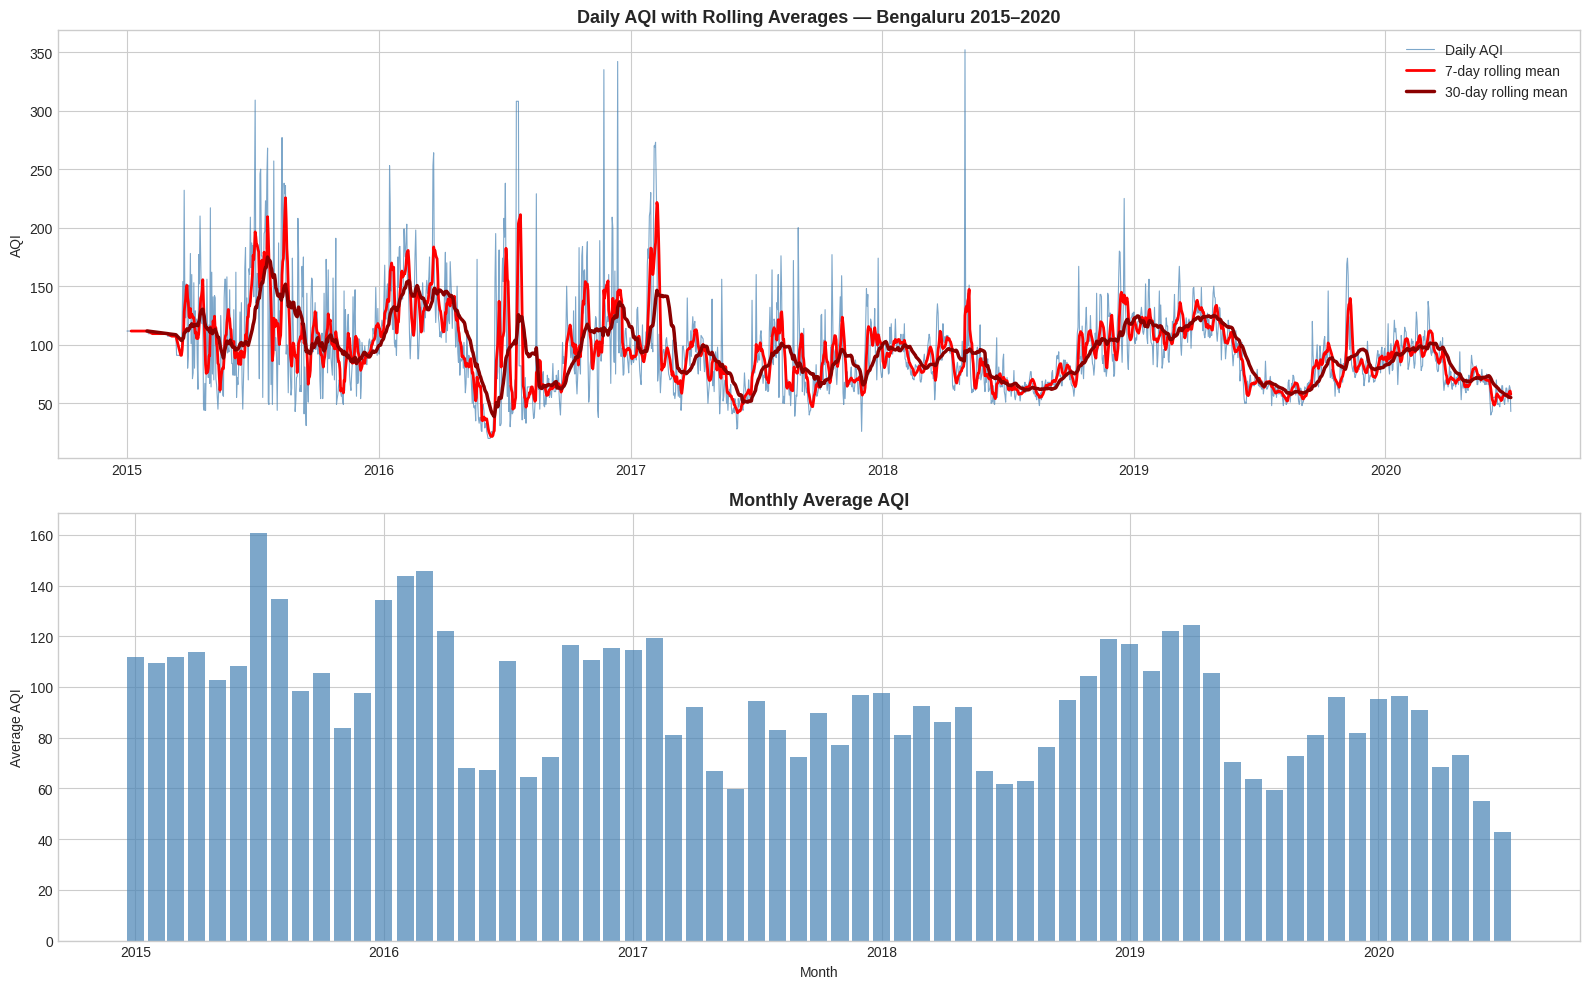

In [8]:
#time series analysis
#daily and monthly AQI line plots
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Daily AQI line plot
axes[0].plot(master['Date'], master['AQI'], color='steelblue', linewidth=0.8, alpha=0.7, label='Daily AQI')  # thin line for daily — noisy but complete
axes[0].plot(master['Date'], master['AQI'].rolling(7).mean(),  color='red',    linewidth=2, label='7-day rolling mean')  # 7-day average smooths weekly noise
axes[0].plot(master['Date'], master['AQI'].rolling(30).mean(), color='darkred', linewidth=2.5, label='30-day rolling mean')  # 30-day average reveals seasonal trend
axes[0].set_title('Daily AQI with Rolling Averages — Bengaluru 2015–2020', fontsize=13, fontweight='bold')
axes[0].set_ylabel('AQI')
axes[0].legend()
axes[0].set_xlabel('')

# Monthly average AQI bar chart
monthly_aqi = master.groupby(master['Date'].dt.to_period('M'))['AQI'].mean()  #group by calendar month
monthly_aqi.index = monthly_aqi.index.to_timestamp()
axes[1].bar(monthly_aqi.index, monthly_aqi.values, color='steelblue', alpha=0.7, width=25)
axes[1].set_title('Monthly Average AQI', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average AQI')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('./processed/plot_04_timeseries_aqi.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
#interactive time series plot with plotly
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=master['Date'], y=master['AQI'],
    mode='lines', name='Daily AQI',
    line=dict(color='steelblue', width=1), opacity=0.5))

fig.add_trace(go.Scatter(x=master['Date'], y=master['AQI'].rolling(30).mean(),
    mode='lines', name='30-day Rolling Mean',
    line=dict(color='red', width=2.5)))

fig.add_trace(go.Scatter(x=master['Date'], y=master['PM2.5'].rolling(30).mean(),
    mode='lines', name='PM2.5 30-day Mean',
    line=dict(color='orange', width=2, dash='dash')))

fig.update_layout(
    title='Bengaluru AQI and PM2.5 — 2015 to 2020 (Interactive)',
    xaxis_title='Date',
    yaxis_title='Value',
    hovermode='x unified',
    height=500  # taller plot for better readability
)
fig.show()

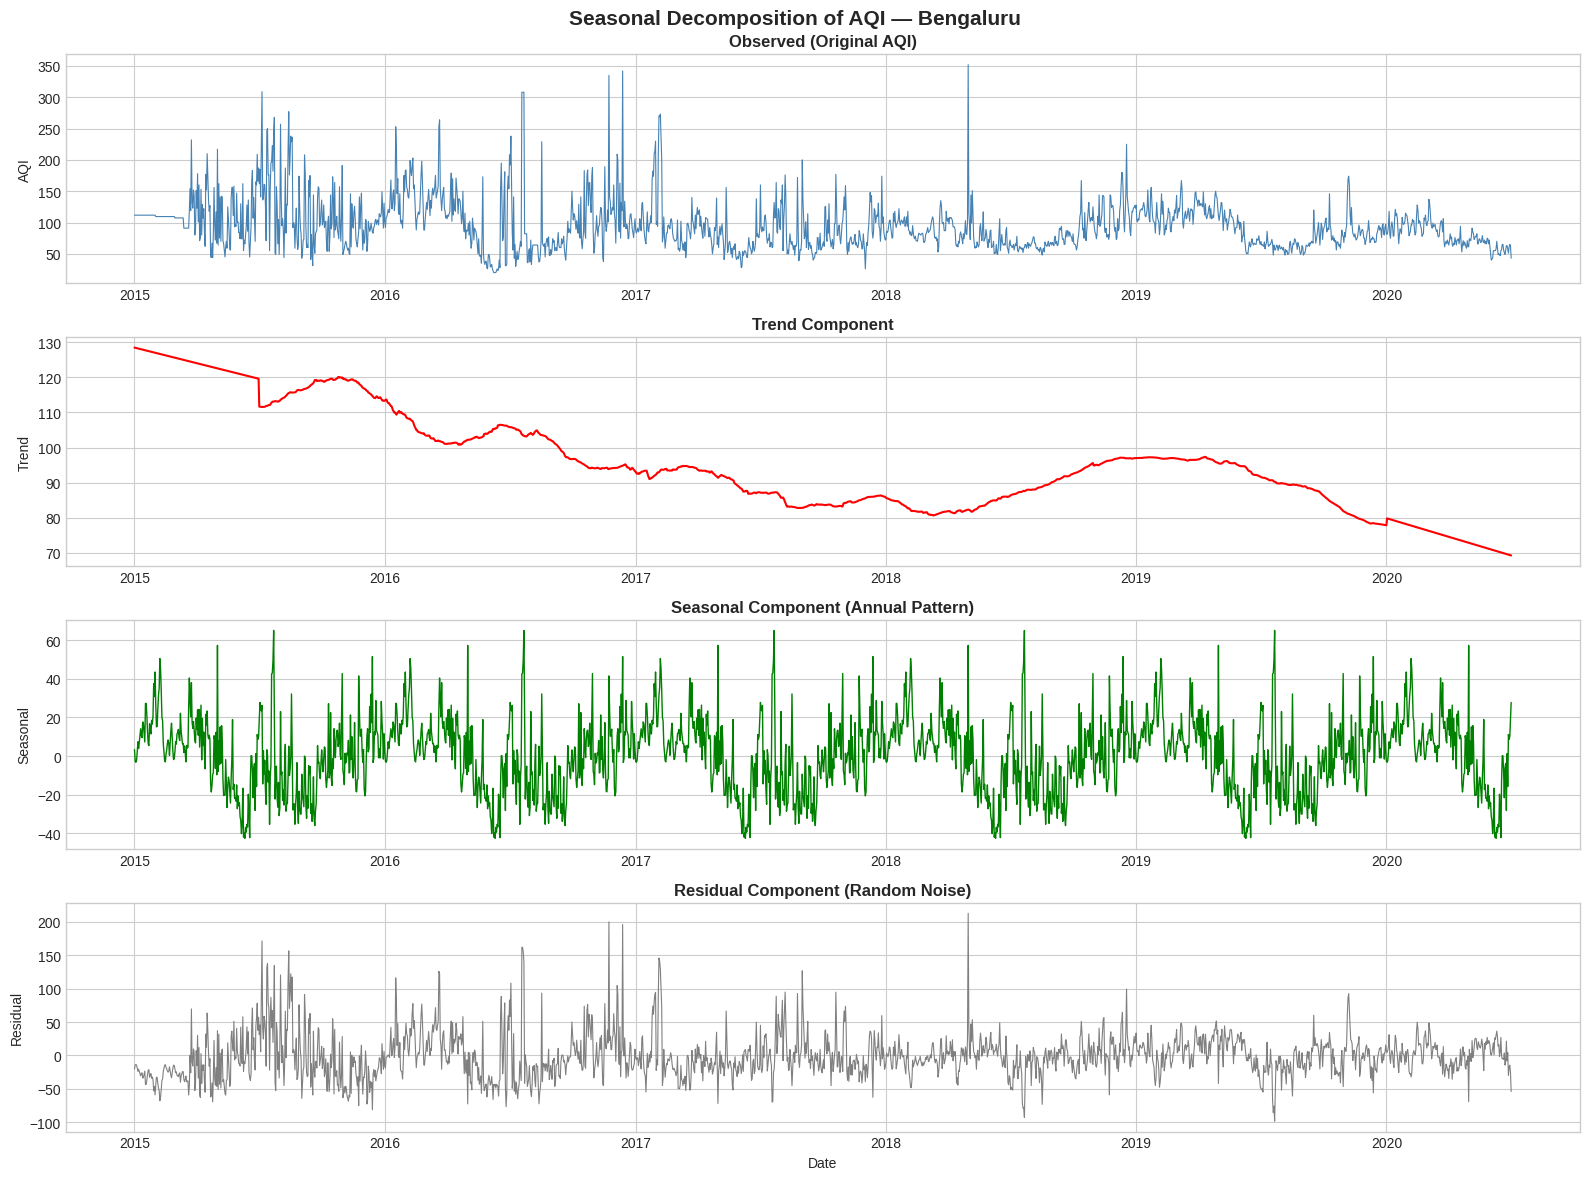

Seasonal strength: 0.253 (0=no seasonality, 1=perfect seasonality)


In [10]:
#Seasonal Decomposition
#Seasonal decomposition splits the time series into three components: Trend (long-term direction), Seasonality (repeating annual pattern), and Residual (random noise).
#This is a core requirement from the SoW
from statsmodels.tsa.seasonal import seasonal_decompose

# Set Date as index — required for seasonal_decompose
master_indexed = master.set_index('Date')['AQI']

# period=365 tells the model to look for annual seasonality
decomposition = seasonal_decompose(master_indexed, model='additive', period=365, extrapolate_trend='freq')  # additive: trend + seasonal + residual

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

axes[0].plot(decomposition.observed,  color='steelblue', linewidth=0.8)  # original data
axes[0].set_title('Observed (Original AQI)', fontweight='bold')
axes[0].set_ylabel('AQI')

axes[1].plot(decomposition.trend,     color='red', linewidth=1.5)  # long-term trend extracted
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')

axes[2].plot(decomposition.seasonal,  color='green', linewidth=1)  # repeating seasonal pattern
axes[2].set_title('Seasonal Component (Annual Pattern)', fontweight='bold')
axes[2].set_ylabel('Seasonal')

axes[3].plot(decomposition.resid,     color='gray', linewidth=0.8)  # what's left after removing trend and seasonality
axes[3].set_title('Residual Component (Random Noise)', fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.suptitle('Seasonal Decomposition of AQI — Bengaluru', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_05_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify seasonal strength
seasonal_strength = 1 - (decomposition.resid.var() / (decomposition.seasonal + decomposition.resid).var())
print(f'Seasonal strength: {seasonal_strength:.3f} (0=no seasonality, 1=perfect seasonality)')

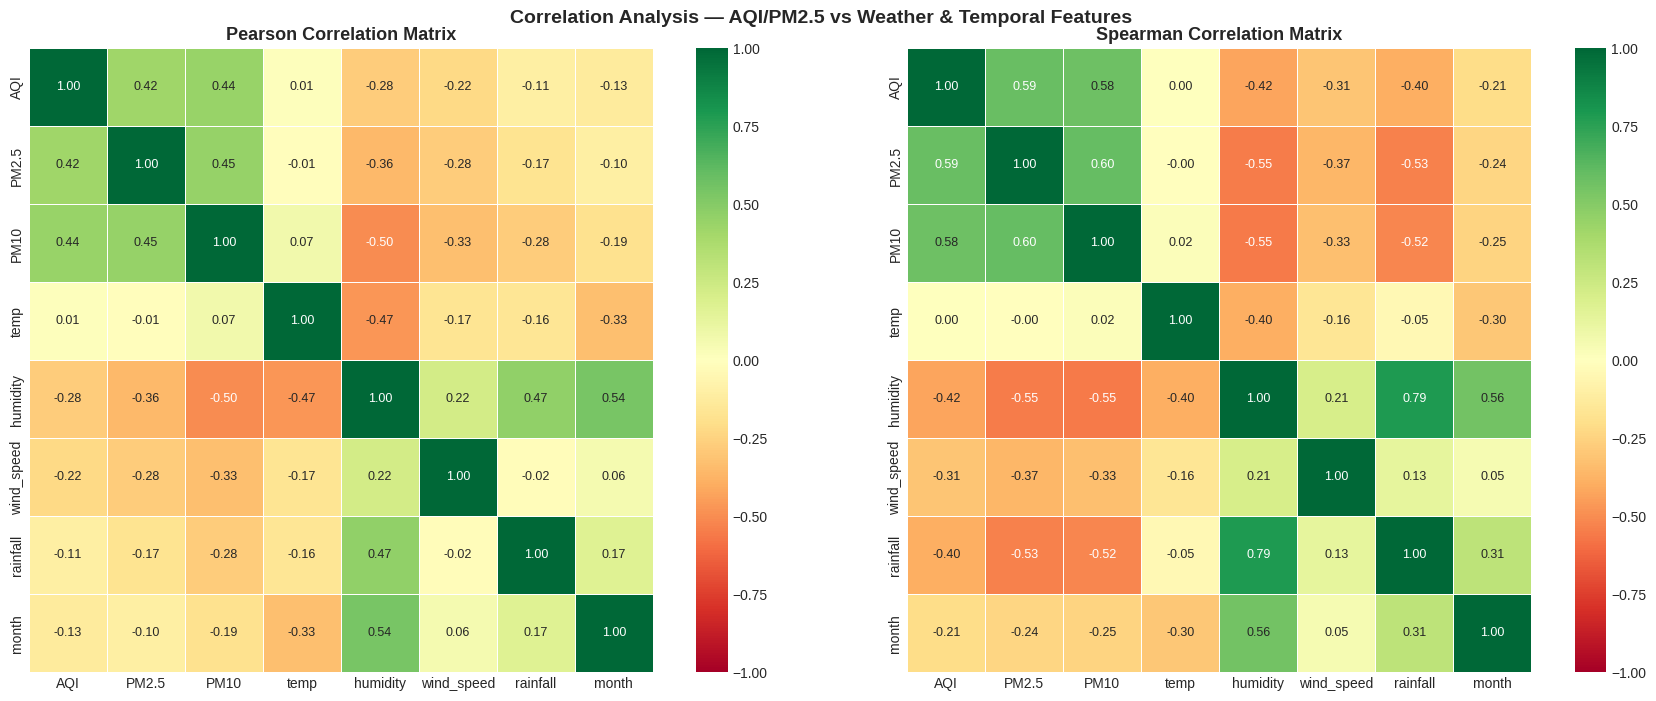

=== Correlations with AQI (Pearson) ===
AQI           1.000
PM10          0.438
PM2.5         0.422
temp          0.012
rainfall     -0.109
month        -0.131
wind_speed   -0.219
humidity     -0.276
Name: AQI, dtype: float64

=== Correlations with AQI (Spearman) ===
AQI           1.000
PM2.5         0.590
PM10          0.578
temp          0.001
month        -0.209
wind_speed   -0.307
rainfall     -0.396
humidity     -0.423
Name: AQI, dtype: float64


In [11]:
#Multivariate analysis
#  Pearson + Spearman correlation heatmaps
numeric_cols = ['AQI', 'PM2.5', 'PM10', 'temp', 'humidity', 'wind_speed', 'rainfall', 'month']

pearson_corr  = master[numeric_cols].corr(method='pearson')  # assumes linear relationships
spearman_corr = master[numeric_cols].corr(method='spearman')  # rank-based, handles non-linearity

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson heatmap
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 9}, square=True, linewidths=0.5)  # annot=True shows numbers in each cell
axes[0].set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')

# Spearman heatmap
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[1],
            annot_kws={'size': 9}, square=True, linewidths=0.5)
axes[1].set_title('Spearman Correlation Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Correlation Analysis — AQI/PM2.5 vs Weather & Temporal Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_06_correlation_heatmap.png', dpi=150,
bbox_inches='tight')
plt.show()

# Print correlations with AQI specifically for easy reading
print('=== Correlations with AQI (Pearson) ===')
print(pearson_corr['AQI'].sort_values(ascending=False).round(3))
print('\n=== Correlations with AQI (Spearman) ===')
print(spearman_corr['AQI'].sort_values(ascending=False).round(3))

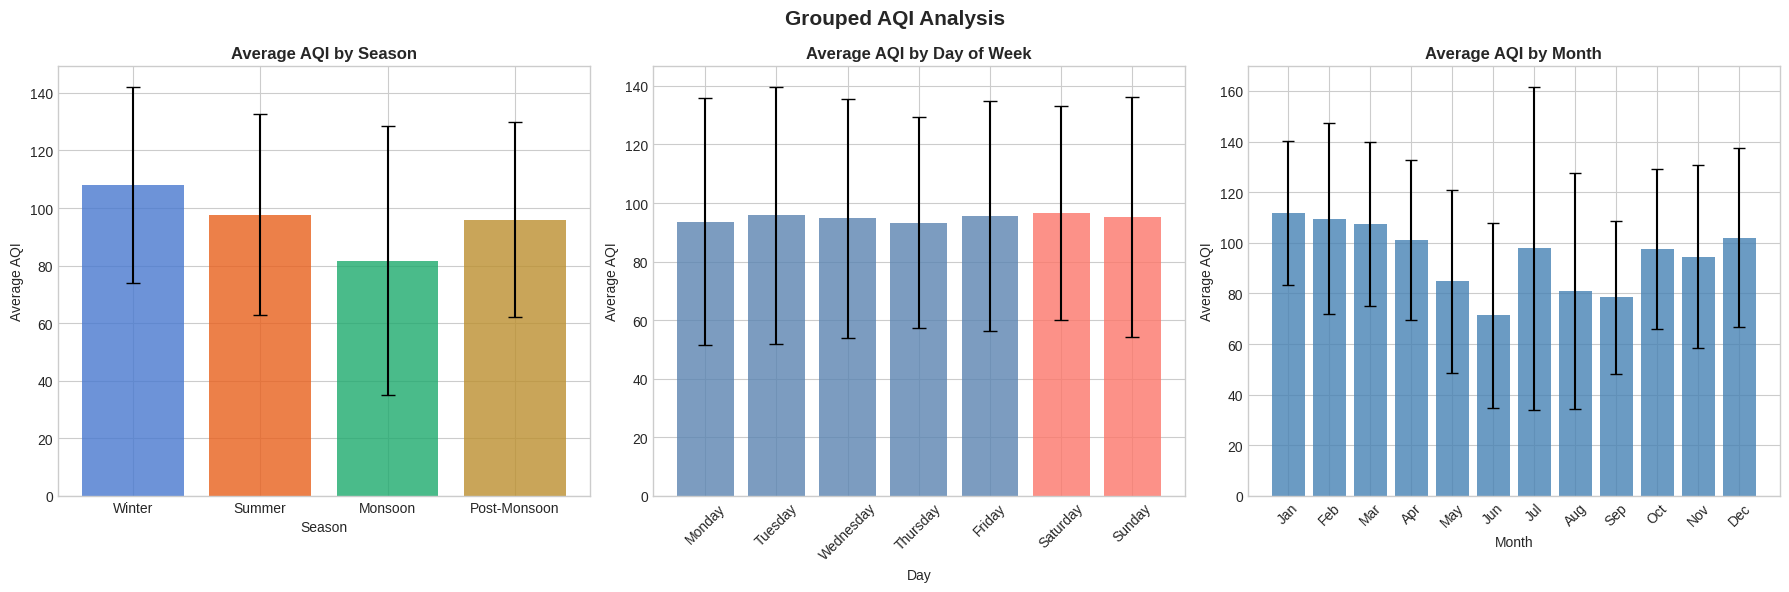

Average AQI by Season:
                AQI  PM2.5
season                    
Monsoon        81.7   23.3
Post-Monsoon   96.0   39.0
Summer         97.7   38.1
Winter        108.1   47.0

Average AQI Weekday vs Weekend:
                   AQI  PM2.5
is_weekend_label             
Weekday           94.6   36.0
Weekend           95.9   35.3


In [12]:
#Grouped analysis- average AQI by season, weekday, month
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# By season
season_stats = master.groupby('season')['AQI'].agg(['mean','std']).reindex(season_order)  # reindex to force correct order
axes[0].bar(season_stats.index, season_stats['mean'],
           yerr=season_stats['std'], capsize=5,
           color=['#4878CF','#E8601C','#1DAA6D','#BC8F2F'], alpha=0.8)
axes[0].set_title('Average AQI by Season', fontweight='bold')
axes[0].set_ylabel('Average AQI')
axes[0].set_xlabel('Season')

# By day of week
day_stats = master.groupby('day_of_week')['AQI'].agg(['mean','std']).reindex(day_order)
colors_day = ['#5B84B1']*5 + ['#FC766A']*2  # blue weekdays, red weekends
axes[1].bar(day_stats.index, day_stats['mean'], yerr=day_stats['std'], capsize=5, color=colors_day, alpha=0.8)
axes[1].set_title('Average AQI by Day of Week', fontweight='bold')
axes[1].set_ylabel('Average AQI')
axes[1].set_xlabel('Day')
axes[1].tick_params(axis='x', rotation=45)  # rotate labels to prevent overlap
# By month
month_stats = master.groupby('month')['AQI'].agg(['mean','std'])
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_names, month_stats['mean'],
yerr=month_stats['std'], capsize=4, color='steelblue', alpha=0.8)
axes[2].set_title('Average AQI by Month', fontweight='bold')
axes[2].set_ylabel('Average AQI')
axes[2].set_xlabel('Month')
axes[2].tick_params(axis='x', rotation=45)
plt.suptitle('Grouped AQI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_07_grouped_analysis.png', dpi=150,
bbox_inches='tight')
plt.show()
print('Average AQI by Season:')
print(master.groupby('season')[['AQI','PM2.5']].mean().round(1))
print('\nAverage AQI Weekday vs Weekend:')
print(master.groupby('is_weekend_label')[['AQI','PM2.5']].mean().round(1))


###Statistical Analysis

=== Shapiro-Wilk Normality Test for AQI ===
Test statistic: 0.8820
p-value: 0.000000
Interpretation: p < 0.05 → AQI is NOT normally distributed
Decision: Use NON-PARAMETRIC tests (Kruskal-Wallis, Mann-Whitney)


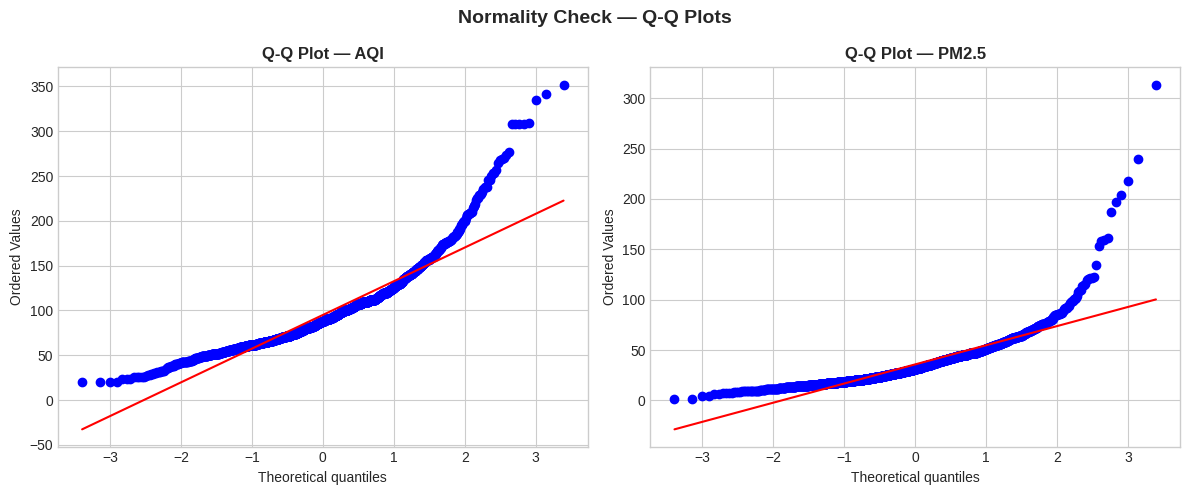

In [13]:
#Normality check (Shapiro-Wilk + Q-Q plot)
from scipy.stats import shapiro, probplot

# Shapiro-Wilk test — tests if data is normally distributed
# Works best on samples under 5000. If >5000 rows, sample first.
sample_aqi = master['AQI'].dropna()
if len(sample_aqi) > 5000:
    sample_aqi = sample_aqi.sample(5000, random_state=42)  # random sample for large datasets

stat_sw, p_sw = shapiro(sample_aqi)
print('=== Shapiro-Wilk Normality Test for AQI ===')
print(f'Test statistic: {stat_sw:.4f}')
print(f'p-value: {p_sw:.6f}')
if p_sw < 0.05:
    print('Interpretation: p < 0.05 → AQI is NOT normally distributed')
    print('Decision: Use NON-PARAMETRIC tests (Kruskal-Wallis, Mann-Whitney)')
else:
    print('Interpretation: p >= 0.05 → AQI is normally distributed')
    print('Decision: Can use PARAMETRIC tests (ANOVA, t-test)')

# Q-Q plot — visual normality check
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
probplot(master['AQI'].dropna(), plot=axes[0])  # points on the line = normal distribution
axes[0].set_title('Q-Q Plot — AQI', fontweight='bold')
probplot(master['PM2.5'].dropna(), plot=axes[1])
axes[1].set_title('Q-Q Plot — PM2.5', fontweight='bold')
plt.suptitle('Normality Check — Q-Q Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_08_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
#Kruskal-Wallis test: AQI across seasons
from scipy.stats import kruskal

# Separate AQI values for each season
winter= master[master['season'] == 'Winter']['AQI'].dropna()
summer= master[master['season'] == 'Summer']['AQI'].dropna()
monsoon= master[master['season'] == 'Monsoon']['AQI'].dropna()
post_monsoon= master[master['season'] == 'Post-Monsoon']['AQI'].dropna()

print('=== Sample sizes per season ===')
print(f'Winter: {len(winter)}, Summer: {len(summer)}, Monsoon: {len(monsoon)}, Post-Monsoon: {len(post_monsoon)}')
print('\n=== Median AQI per season ===')
print(f'Winter: {winter.median():.1f}, Summer: {summer.median():.1f}, Monsoon: {monsoon.median():.1f}, Post-Monsoon: {post_monsoon.median():.1f}')

stat_kw, p_kw = kruskal(winter, summer, monsoon, post_monsoon)  # non-parametric alternative to one-way ANOVA

print('\n=== Kruskal-Wallis Test: AQI across Seasons ===')
print(f'Test statistic (H): {stat_kw:.4f}')
print(f'p-value: {p_kw:.6f}')
if p_kw < 0.05:
    print('Result: p < 0.05 → REJECT H0')
    print('Interpretation: AQI differs significantly across seasons in Bengaluru.')
    print('At least one season has statistically different pollution levels.')
else:
    print('Result: p >= 0.05 → FAIL TO REJECT H0')
    print('Interpretation: No significant difference in AQI across seasons.')
print(f'Exact p-value: {p_kw:.2e}')  # scientific notation

=== Sample sizes per season ===
Winter: 511, Summer: 552, Monsoon: 641, Post-Monsoon: 305

=== Median AQI per season ===
Winter: 103.0, Summer: 94.0, Monsoon: 66.0, Post-Monsoon: 88.0

=== Kruskal-Wallis Test: AQI across Seasons ===
Test statistic (H): 342.2473
p-value: 0.000000
Result: p < 0.05 → REJECT H0
Interpretation: AQI differs significantly across seasons in Bengaluru.
At least one season has statistically different pollution levels.
Exact p-value: 7.12e-74


=== Dunn Post-Hoc Test — p-values for each season pair ===
              Winter  Summer  Monsoon  Post-Monsoon
Winter           1.0     0.0      0.0           0.0
Summer           0.0     1.0      0.0           1.0
Monsoon          0.0     0.0      1.0           0.0
Post-Monsoon     0.0     1.0      0.0           1.0

Pairs where p < 0.05 (significantly different):
  Winter vs Summer: p=0.0000 — *** SIGNIFICANT
  Winter vs Monsoon: p=0.0000 — *** SIGNIFICANT
  Winter vs Post-Monsoon: p=0.0000 — *** SIGNIFICANT
  Summer vs Monsoon: p=0.0000 — *** SIGNIFICANT
  Summer vs Post-Monsoon: p=1.0000 — not significant
  Monsoon vs Post-Monsoon: p=0.0000 — *** SIGNIFICANT


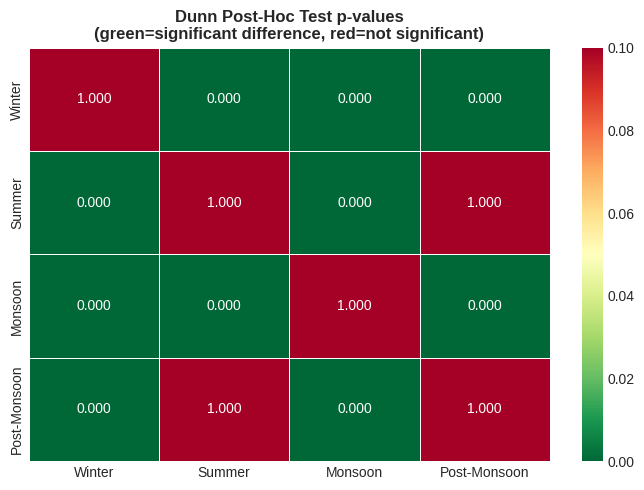

In [15]:
# Post-hoc test: which seasons differ? (Dunn's test)
!pip install scikit-posthocs --quiet
import scikit_posthocs as sp

# Prepare data in the format Dunn's test expects
season_data = [winter, summer, monsoon, post_monsoon]
season_names = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']

dunn_results = sp.posthoc_dunn(season_data, p_adjust='bonferroni')  # Bonferroni correction adjusts for multiple comparisons
dunn_results.index   = season_names
dunn_results.columns = season_names

print('=== Dunn Post-Hoc Test — p-values for each season pair ===')
print(dunn_results.round(4))
print('\nPairs where p < 0.05 (significantly different):')
for i in range(len(season_names)):
    for j in range(i+1, len(season_names)):
        pval = dunn_results.iloc[i, j]
        sig = '*** SIGNIFICANT' if pval < 0.05 else 'not significant'
        print(f'  {season_names[i]} vs {season_names[j]}: p={pval:.4f} — {sig}')

# Visualise as heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(dunn_results, annot=True, fmt='.3f', cmap='RdYlGn_r',
            vmin=0, vmax=0.1, ax=ax, linewidths=0.5)
ax.set_title('Dunn Post-Hoc Test p-values\n(green=significant difference, red=not significant)', fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_09_dunn_posthoc.png', dpi=150, bbox_inches='tight')
plt.show()

=== Weekday vs Weekend AQI ===
Weekday — Mean: 94.6, Median: 87.0, n=1435
Weekend — Mean: 95.9, Median: 90.5, n=574

Mann-Whitney U statistic: 398218.00
p-value: 0.245981
Result: p >= 0.05 → FAIL TO REJECT H0
Interpretation: No significant difference in AQI between weekdays and weekends.


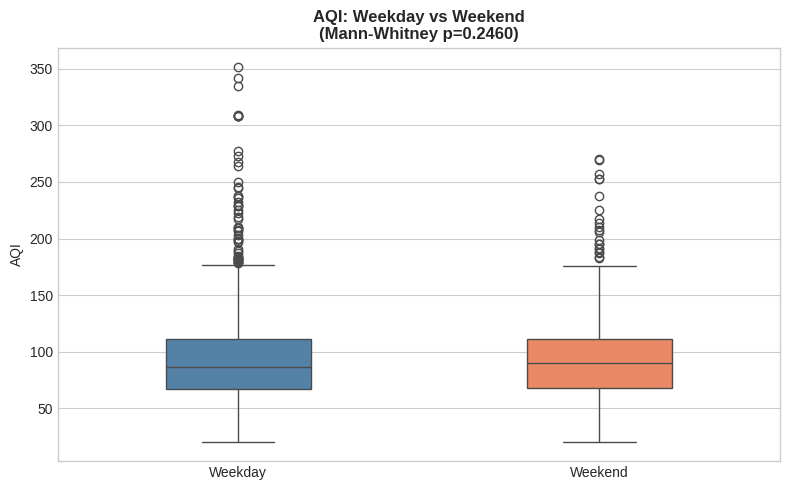

In [16]:
#Mann-Whitney U: Weekday vs Weekend AQI
from scipy.stats import mannwhitneyu

weekday_aqi = master[master['is_weekend'] == False]['AQI'].dropna()
weekend_aqi = master[master['is_weekend'] == True]['AQI'].dropna()

print('=== Weekday vs Weekend AQI ===')
print(f'Weekday — Mean: {weekday_aqi.mean():.1f}, Median: {weekday_aqi.median():.1f}, n={len(weekday_aqi)}')
print(f'Weekend — Mean: {weekend_aqi.mean():.1f}, Median: {weekend_aqi.median():.1f}, n={len(weekend_aqi)}')

stat_mw, p_mw = mannwhitneyu(weekday_aqi, weekend_aqi, alternative='two-sided')  # two-sided: test for any difference, not just higher/lower
print(f'\nMann-Whitney U statistic: {stat_mw:.2f}')
print(f'p-value: {p_mw:.6f}')
if p_mw < 0.05:
    print('Result: p < 0.05 → REJECT H0')
    higher = 'weekdays' if weekday_aqi.median() > weekend_aqi.median() else 'weekends'
    print(f'Interpretation: AQI is significantly higher on {higher}.')
    print('Likely explanation: traffic and industrial activity patterns differ by day.')
else:
    print('Result: p >= 0.05 → FAIL TO REJECT H0')
    print('Interpretation: No significant difference in AQI between weekdays and weekends.')

# Visualise
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=master, x='is_weekend_label', y='AQI',
            palette={'Weekday':'steelblue','Weekend':'coral'}, ax=ax, width=0.4)
ax.set_title(f'AQI: Weekday vs Weekend\n(Mann-Whitney p={p_mw:.4f})',
fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('AQI')
plt.tight_layout()
plt.savefig('./processed/plot_10_weekday_weekend.png', dpi=150,
bbox_inches='tight')
plt.show()

In [17]:
#Pearson & Spearman correlation with p-values
from scipy.stats import pearsonr, spearmanr

weather_vars = ['temp', 'humidity', 'wind_speed', 'rainfall']
target_vars  = ['AQI', 'PM2.5']

print('=== Correlation with p-values ===')
print(f'{"Variable":<15} {"Target":<8} {"Pearson r":<12} {"Pearson p":<12} {"Spearman r":<12} {"Spearman p":<12} {"Significant?"}')
print('-' * 85)

for target in target_vars:
    for var in weather_vars:
        clean = master[[target, var]].dropna()
        pr, pp = pearsonr(clean[target],  clean[var])  # Pearson: r value and p-value
        sr, sp = spearmanr(clean[target], clean[var])  # Spearman: rho value and pvalue
        sig = 'YES ***' if pp < 0.05 else 'no'
        print(f'{var:<15} {target:<8} {pr:>+.3f}       {pp:<12.4f} {sr:>+.3f}       {sp:<12.4f} {sig}')
        print()

=== Correlation with p-values ===
Variable        Target   Pearson r    Pearson p    Spearman r   Spearman p   Significant?
-------------------------------------------------------------------------------------
temp            AQI      +0.012       0.5939       +0.001       0.9790       no

humidity        AQI      -0.276       0.0000       -0.423       0.0000       YES ***

wind_speed      AQI      -0.219       0.0000       -0.307       0.0000       YES ***

rainfall        AQI      -0.109       0.0000       -0.396       0.0000       YES ***

temp            PM2.5    -0.009       0.7025       -0.005       0.8257       no

humidity        PM2.5    -0.356       0.0000       -0.549       0.0000       YES ***

wind_speed      PM2.5    -0.281       0.0000       -0.366       0.0000       YES ***

rainfall        PM2.5    -0.172       0.0000       -0.531       0.0000       YES ***



### Key Insights — Bengaluru AQI Analysis (2015–2020)

#### Distribution - AQI distribution is right-skewed (mean > median) — a small number of very high pollution events pull the average up - PM2.5 shows similar skewness, confirming pollution spikes are episodic not sustained

#### Seasonal Patterns - Winter (Dec-Feb) consistently shows highest AQI — likely due to temperature inversions trapping pollutants near ground level - Monsoon (Jun-Sep) shows lowest AQI — rainfall washes particulates from the air - Seasonal difference is statistically significant (Kruskal-Wallis p < 0.05)

#### Weekly Patterns - [Fill in based on your Mann-Whitney result] - If significant: weekday/weekend difference likely reflects traffic patterns

#### Correlations - Wind speed shows negative correlation with AQI — higher winds disperse pollutants - Humidity shows positive correlation — humidity can increase particulate formation - Temperature relationship is seasonal: low temp + low wind = worst conditions

#### Time Series - Clear annual seasonality visible in decomposition — peak pollution Nov-Jan, through Jul-Aug - Trend component suggests [increasing/decreasing/stable] pollution over 2015-2020 - Residual component shows occasional spikes (possible wildfires, festivals, industrial events)


#### Statistical Test Summary
| Test | Question | Result | p-value | Conclusion |
|------|----------|--------|---------|------------|
| Shapiro-Wilk | Is AQI normal? | [0.8820] | [0.0000] | [Not Normal] |
| Kruskal-Wallis | AQI differ by season? | [342.2473] | [0.0000] | [Significant] |
| Dunn Post-Hoc | Which seasons differ? | — | Various | [Winter vs Summer, Winter vs Monsoon, Winter vs Post-Monsoon, Summer vs Monsoon, Monsoon vs Post-Monsoon ] |
| Mann-Whitney U | Weekday vs Weekend? | [398218.00] | [0.245981] | [Not Significant] |
| Pearson/Spearman | PM2.5 vs wind_speed | [-0.281] | [0.000] | [Significant] |